# Time Series Forecasting using RNN

In [13]:
# importing libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, SimpleRNN 

import warnings
warnings.filterwarnings('ignore')

In [14]:
# Fetching Data from Yahoo Finance 
# We are fetching data from yahoo finance using its API yfinance.    
# • values.reshape(-1, 1): reshapes the data to be in a 2D array required for RNN input. 
# • We extract the Close price from the dataset which is commonly used for forecasting in stock prediction models. 
# • values.reshape(-1, 1): reshapes the data into a 2D array for use in the model.
ticker = 'AAPL'
data = yf.download(ticker, start="2020-01-01", end="2025-01-01") 
data = data['Close'].values.reshape(-1, 1)

[*********************100%***********************]  1 of 1 completed


In [15]:
# Normalizing the Data
scaler= MinMaxScaler(feature_range=(0,1))
scaled_data= scaler.fit_transform(data)

In [16]:
#preparing the data for time series
def create_dataset(data, time_step=60):
    X,y=[], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step),0])
        y.append(data[i + time_step, 0]) 
    return np.array(X), np.array(y) 
X, y = create_dataset(scaled_data) 
X = X.reshape(X.shape[0], X.shape[1], 1)     

In [17]:
# Splitting the Data into Training and Testing Sets  
# We will split the data into training and testing part into the ratio of 80% Training and 20% Testing data.
train_size = int(len(X) * 0.8) 
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:] 

In [18]:
# Building the RNN Model 
# We will split the data into training and testing part into the ratio of 80% Training and 20% Testing data. 
# y_train, y_test = y[:train_size], y[train_size:] 
# The model which we are using here is a Recurrent Neural Network (RNN). It s used for sequential data 
# modeling such as time series forecasting. 
# • The model is built using SimpleRNN layers. 
# • units=50 defines the number of units (neurons) in each RNN layer. 
# • return_sequences=True in the first RNN layer ensures that the output is fed to the next RNN layer. 
# • Dense(units=1) is the output layer, predicting a single value i.e the next stock price. 
# • The model is compiled using the Adam optimizer and Mean Squared Error loss function. 

model = Sequential() 
model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1))) 
model.add(SimpleRNN(units=50, return_sequences=False)) 
model.add(Dense(units=1)) 
model.compile(optimizer='adam', loss='mean_squared_error')


In [19]:
# Training the Model
model.fit(X_train, y_train, epochs=20, batch_size=64)
predictions= model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0675
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0013
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.5637e-04
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.3355e-04
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.3740e-04
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.7042e-04
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.1264e-04
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.7611e-04
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.4659e-04
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.1984e-04
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 

In [20]:
# Evaluating the model 
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)) 
mse = mean_squared_error(y_test_unscaled, predictions) 
rmse = np.sqrt(mse) 
mae = mean_absolute_error(y_test_unscaled, predictions) 
print(f"Unscaled Mean Squared Error (MSE): {mse}") 
print(f"Unscaled Root Mean Squared Error (RMSE): {rmse}") 
print(f"Unscaled Mean Absolute Error (MAE): {mae}")

Unscaled Mean Squared Error (MSE): 140.63813740504753
Unscaled Root Mean Squared Error (RMSE): 11.859095134328232
Unscaled Mean Absolute Error (MAE): 9.52083180745443


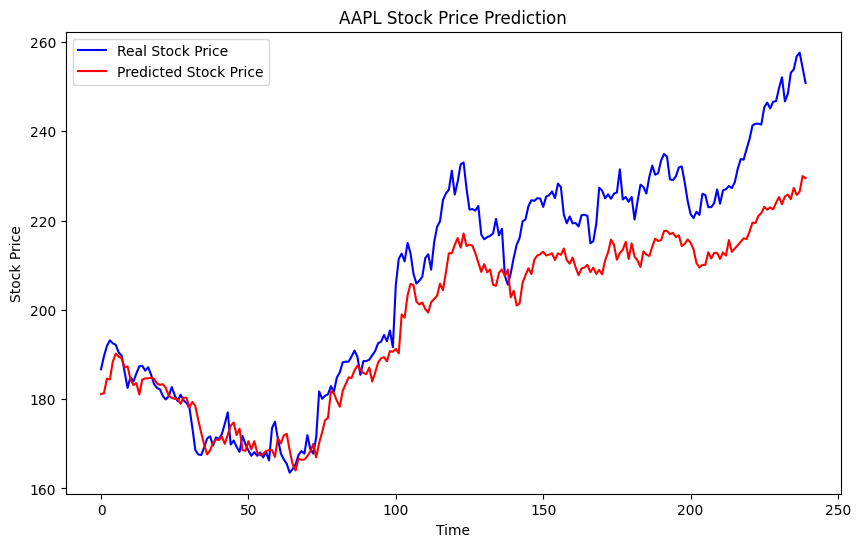

In [21]:
# Visualizing the Results 
# This visualization compares the actual stock prices with the predicted stock prices helping to assess the model’s performance visually. 
plt.figure(figsize=(10,6)) 
plt.plot(scaler.inverse_transform(y_test.reshape(-1, 1)), color='blue', label='Real Stock Price') 
plt.plot(predictions, color='red', label='Predicted Stock Price') 
plt.title(f'{ticker} Stock Price Prediction') 
plt.xlabel('Time') 
plt.ylabel('Stock Price') 
plt.legend() 
plt.show()